# Deep Neural Networks
You should build an end-to-end machine learning pipeline using a deep learning model. In particular, you should do the following:
- Load the `fashion mnist` dataset from [TensorFlow](https://www.tensorflow.org/tutorials/keras/classification). The loaded dataset is already split into training and test sets.
- Build an end-to-end machine learning pipeline, including a [deep learning](https://www.tensorflow.org/tutorials/keras/classification) model.
- Optimize your pipeline by validating your design decisions.
- Test the best pipeline on the test set and report various [evaluation metrics](https://scikit-learn.org/0.15/modules/model_evaluation.html).  
- Check the documentation to identify the most important hyperparameters, attributes, and methods of the model. Use them in practice.

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [3]:
print("Training set shape:", train_images.shape)
print("Test set shape:", test_images.shape)
print("Number of training samples:", train_images.shape[0])
print("Number of test samples:", test_images.shape[0])
print("Image dimensions:", train_images.shape[1:])

Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of training samples: 60000
Number of test samples: 10000
Image dimensions: (28, 28)


In [4]:
unique_train_labels, counts_train = np.unique(train_labels, return_counts=True)

print("Training set label distribution:")
for label, count in zip(unique_train_labels, counts_train):
    print(f"Label {label}: {count} samples")


Training set label distribution:
Label 0: 6000 samples
Label 1: 6000 samples
Label 2: 6000 samples
Label 3: 6000 samples
Label 4: 6000 samples
Label 5: 6000 samples
Label 6: 6000 samples
Label 7: 6000 samples
Label 8: 6000 samples
Label 9: 6000 samples


In [5]:
class_images_dict = {}
for i in range(10):
    class_images_dict[i] = train_images[train_labels == i]

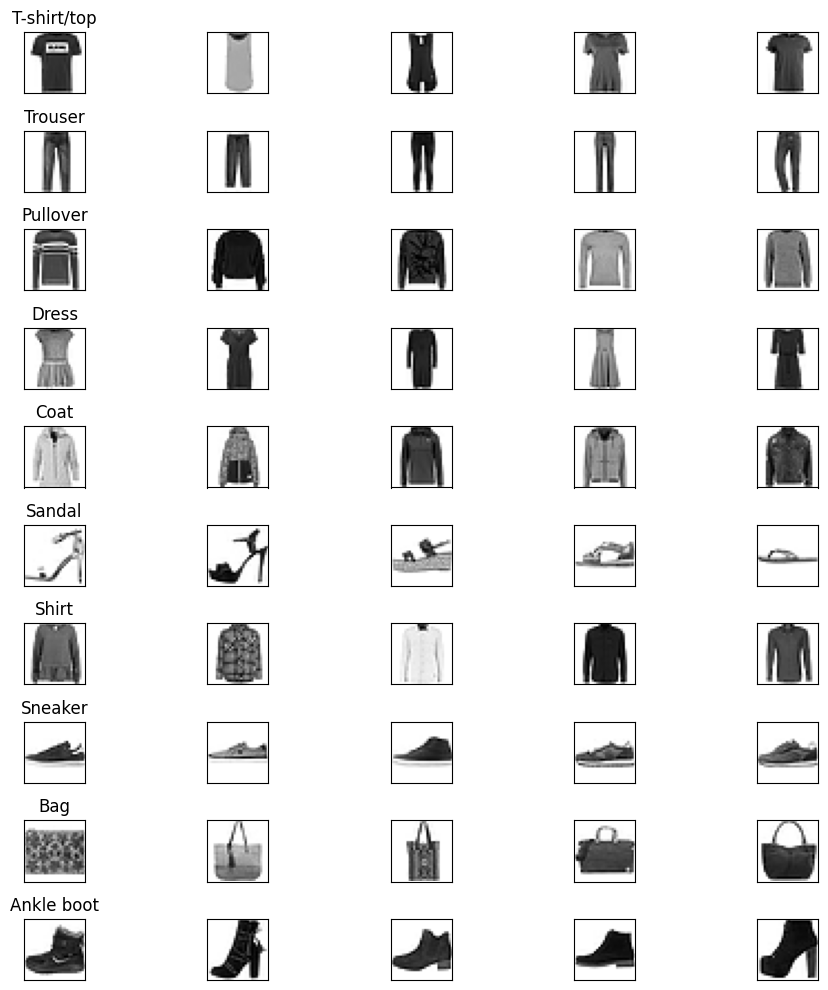

In [6]:
class_num = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 10))
for class_label in range(10):
    class_name = class_num[class_label]
    images_to_plot = class_images_dict[class_label][:5]

    for i in range(5):
        plt.subplot(10, 5, class_label * 5 + i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images_to_plot[i], cmap=plt.cm.binary)
        if i == 0:
            plt.title(class_num[class_label])

plt.tight_layout
plt.tight_layout()
plt.show()


In [7]:
model = tf.keras.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64)
])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,248 (426.75 KB)

 Trainable params: 108,992 (425.75 KB)

 Non-trainable params: 256 (1.00 KB)

In [8]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=20, validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7596 - loss: 0.8294 - val_accuracy: 0.8271 - val_loss: 0.5419
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8399 - loss: 0.4535 - val_accuracy: 0.8473 - val_loss: 0.5069
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8472 - loss: 0.4328 - val_accuracy: 0.8468 - val_loss: 0.5634
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8517 - loss: 0.4090 - val_accuracy: 0.8621 - val_loss: 0.5262
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8583 - loss: 0.3931 - val_accuracy: 0.8600 - val_loss: 0.5651
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8659 - loss: 0.3822 - val_accuracy: 0.8721 - val_loss: 0.4746
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8675 - loss: 0.3746 - val_accuracy: 0.8657 - val_loss: 0.5690
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8638 - loss: 0.3765

In [9]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath='best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

best_model = tf.keras.models.load_model('best_model.h5')

test_loss, test_acc = best_model.evaluate(test_images, test_labels, verbose=2)
print('\nTest accuracy of the best model:', test_acc)

313/313 - 1s - 3ms/step - accuracy: 0.8594 - loss: 0.8311

Test accuracy of the best model: 0.8593999743461609


In [12]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 1s - 3ms/step - accuracy: 0.8680 - loss: 0.5597

Test accuracy: 0.8679999709129333
